## Import libraries and data loader

In [143]:
import pandas as pd 
import numpy as np

In [144]:
# Cá ngừ
tn_fish_path = pd.read_csv('../dataset/gbif_asia_full/gbif_asis_full_thunnus_south.csv', sep='\t')
tn_fish_path.shape

(453, 18)

In [145]:
# Cá thu
sc_fish_path = pd.read_csv('../dataset/gbif_asia_full/gbif_asia_full_scomber_cathu.csv', sep='\t')
sc_fish_path.shape

(1036, 18)

In [146]:
# Cá trích
sa_fish_path = pd.read_csv('../dataset/gbif_asia_full/gbif_asia_full_sardinnella.csv', sep='\t')
sa_fish_path.shape

(1792, 18)

Nhóm cá thu ngừ: family là scombridae
- Nhóm Cá ngừ: tập trung vào các genus là ['Thunnus', 'Katsuwonus', 'Euthynnus', 'Auxis']
- Nhóm Cá thu: tập trung vào các genus là ['Scomber', 'Scomberomorus', 'Acanthocybium']

In [147]:
# Family scombridae
family_scombridae = pd.read_csv('../dataset/gbif_asia_full/gbif_asia_family_scombridae_2020_2026.csv', sep='\t')
family_scombridae.shape

(936, 18)

In [148]:
# Filter cá ngừ và cá thu

# 1. Định nghĩa danh sách các chi (Genus)
list_ca_ngu = ['Thunnus', 'Katsuwonus', 'Euthynnus', 'Auxis']
list_ca_thu = ['Scomber', 'Scomberomorus', 'Acanthocybium']

# 2. Tạo một cột mới gọi là 'nhom_ca' để phân loại
# Sử dụng .loc để gán nhãn
family_scombridae.loc[family_scombridae['genus'].isin(list_ca_ngu), 'fish_type'] = 'Ca Ngu'
family_scombridae.loc[family_scombridae['genus'].isin(list_ca_thu), 'fish_type'] = 'Ca Thu'

# 3. Loại bỏ những dòng không thuộc 2 nhóm trên (nếu cần)
genus_thu_ngu = family_scombridae[family_scombridae['fish_type'].notna()]

# Kiểm tra kết quả
print(family_scombridae['fish_type'].value_counts())

fish_type
Ca Thu    313
Ca Ngu    280
Name: count, dtype: int64


In [149]:
# Family clupeidae - cá trích
family_clupeidae = pd.read_csv('../dataset/gbif_asia_full/gbif_asia_family_clupeidae_2020_2026.csv', sep='\t')

# Thêm 1 cột fish_type = 'Ca Trich' 
family_clupeidae['fish_type'] = 'Ca Trich'
family_clupeidae.shape

(1684, 19)

In [150]:
# Read and concat to get gbif_data
# gbif_data = pd.concat([tn_fish_path, sc_fish_path, sa_fish_path], ignore_index=True)
gbif_data = pd.concat([family_clupeidae, genus_thu_ngu], ignore_index=True)

In [151]:
print(gbif_data.shape)

(2277, 19)


In [152]:
gbif_data.head(5)

,gbifID,family,genus,species,countryCode,stateProvince,occurrenceStatus,individualCount,decimalLatitude,decimalLongitude,coordinateUncertaintyInMeters,depth,depthAccuracy,eventDate,day,month,year,basisOfRecord,fish_type
0,5069193733,Clupeidae,Amblygaster,Amblygaster sirm,TW,NaN,PRESENT,2.0,22.838060,121.189425,NaN,NaN,NaN,2020-03-10,10.0,3.0,2020,PRESERVED_SPECIMEN,Ca Trich
1,5069190053,Clupeidae,Amblygaster,Amblygaster sirm,TW,NaN,PRESENT,1.0,22.836917,121.189351,NaN,NaN,NaN,2021-06-09,9.0,6.0,2021,PRESERVED_SPECIMEN,Ca Trich
2,4930326497,Clupeidae,Anodontostoma,Anodontostoma chacunda,MY,NaN,PRESENT,1.0,5.679000,102.712200,NaN,5.0,5.0,2022-01-17,17.0,1.0,2022,PRESERVED_SPECIMEN,Ca Trich
3,4930326656,Clupeidae,Anodontostoma,Anodontostoma chacunda,MY,NaN,PRESENT,1.0,5.668000,102.735000,NaN,5.0,5.0,2023-01-25,25.0,1.0,2023,PRESERVED_SPECIMEN,Ca Trich
4,5865123310,Clupeidae,Anodontostoma,Anodontostoma chacunda,BD,NaN,PRESENT,NaN,21.703521,89.261482,NaN,NaN,NaN,2023-01-09,9.0,1.0,2023,MACHINE_OBSERVATION,Ca Trich


In [153]:
print(gbif_data.columns.tolist())

['gbifID', 'family', 'genus', 'species', 'countryCode', 'stateProvince', 'occurrenceStatus', 'individualCount', 'decimalLatitude', 'decimalLongitude', 'coordinateUncertaintyInMeters', 'depth', 'depthAccuracy', 'eventDate', 'day', 'month', 'year', 'basisOfRecord', 'fish_type']


In [154]:
print(gbif_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2277 entries, 0 to 2276
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   gbifID                         2277 non-null   int64  
 1   family                         2277 non-null   object 
 2   genus                          2202 non-null   object 
 3   species                        2134 non-null   object 
 4   countryCode                    2277 non-null   object 
 5   stateProvince                  1105 non-null   object 
 6   occurrenceStatus               2277 non-null   object 
 7   individualCount                377 non-null    float64
 8   decimalLatitude                2256 non-null   float64
 9   decimalLongitude               2256 non-null   float64
 10  coordinateUncertaintyInMeters  723 non-null    float64
 11  depth                          16 non-null     float64
 12  depthAccuracy                  15 non-null     f

In [155]:
categorical_columns = ['family', 'genus', 'species', 'occurrenceStatus','countryCode', 'stateProvince']
for col in categorical_columns:
    unique_values = gbif_data[col].unique()
    print(f"Unique values in column '{col}': {unique_values}")

Unique values in column 'family': ['Clupeidae' 'Scombridae']
Unique values in column 'genus': ['Amblygaster' 'Anodontostoma' 'Hilsa' 'Gudusia' 'Ehirava' 'Corica'
 'Clupea' nan 'Escualosa' 'Herklotsichthys' 'Konosirus' 'Nematalosa'
 'Sardina' 'Sardinella' 'Sardinops' 'Tenualosa' 'Alosa' 'Spratelloides'
 'Clupeichthys' 'Clupeoides' 'Sprattus' 'Clupanodon' 'Sundasalanx'
 'Clupeonella' 'Euthynnus' 'Scomber' 'Scomberomorus' 'Thunnus'
 'Acanthocybium' 'Auxis' 'Katsuwonus']
Unique values in column 'species': ['Amblygaster sirm' 'Anodontostoma chacunda' 'Hilsa kelee'
 'Gudusia chapra' 'Ehirava fluviatilis' 'Corica soborna' nan
 'Clupea harengus' 'Escualosa thoracata' 'Konosirus punctatus'
 'Nematalosa come' 'Nematalosa galatheae' 'Nematalosa japonica'
 'Nematalosa nasus' 'Sardina pilchardus' 'Sardinella albella'
 'Sardinella gibbosa' 'Sardinella hualiensis' 'Sardinella jussieu'
 'Sardinella lemuru' 'Sardinella melanura' 'Sardinops sagax'
 'Tenualosa ilisha' 'Alosa immaculata' 'Herklotsichthys 

Xử lý null, quan trọng nhất là species, decimalLongitude, decimalLatitude, và eventDate
- eventDate đã check, ko thể convert ngược lại từ day, month, year => remove cột null
- Convert dạng timestamp của eventDate, và đối với day, month, year bị null -> xử lý để lấy dữ liệu luôn 
- Đối với species null => <genus_other>

In [156]:
# Column eventDate
gbif_data_subset = gbif_data.dropna(subset=['eventDate'])

# Remove dữ liệu trước 1990
gbif_data_subset = gbif_data_subset[gbif_data_subset['year'] >= 1990]


In [157]:
gbif_data_subset["eventDate"] = (
    gbif_data_subset["eventDate"]
    .astype(str)
    .str.strip()
)
gbif_data_subset["datetime"] = pd.to_datetime(
    gbif_data_subset["eventDate"],
    errors="coerce",
    format="mixed",
    utc=True
)

# Có trường hợp xuất hiện interval time ví dụ dạng 2006-03-01/2006-03-31
# Dùng split('/') để tách chuỗi và lấy phần tử đầu tiên
gbif_data_subset["eventDate"] = gbif_data_subset["eventDate"].str.split('/').str[0]


# Chỉ lấy ngày và update lại cột năm
gbif_data_subset["date"] = gbif_data_subset['datetime'].dt.date
gbif_data_subset["year"] = gbif_data_subset['datetime'].dt.year

In [158]:
print(gbif_data_subset[gbif_data_subset['eventDate'].isna()])
print(gbif_data_subset[gbif_data_subset['year'].isna()])

Empty DataFrame
Columns: [gbifID, family, genus, species, countryCode, stateProvince, occurrenceStatus, individualCount, decimalLatitude, decimalLongitude, coordinateUncertaintyInMeters, depth, depthAccuracy, eventDate, day, month, year, basisOfRecord, fish_type, datetime, date]
Index: []

[0 rows x 21 columns]
          gbifID     family      genus              species countryCode  \
1158  4522096948  Clupeidae  Konosirus  Konosirus punctatus          JP   
1159  4522096167  Clupeidae  Konosirus  Konosirus punctatus          JP   
1160  4522099473  Clupeidae  Konosirus  Konosirus punctatus          JP   
1161  4522105119  Clupeidae  Konosirus  Konosirus punctatus          JP   

     stateProvince occurrenceStatus  individualCount  decimalLatitude  \
1158       Fukuoka          PRESENT              NaN        33.666667   
1159       Fukuoka          PRESENT              NaN        33.666667   
1160       Fukuoka          PRESENT              NaN        33.666667   
1161       Fukuoka 

In [159]:
gbif_data_subset.head(5)

,gbifID,family,genus,species,countryCode,stateProvince,occurrenceStatus,individualCount,decimalLatitude,decimalLongitude,...,depth,depthAccuracy,eventDate,day,month,year,basisOfRecord,fish_type,datetime,date
0,5069193733,Clupeidae,Amblygaster,Amblygaster sirm,TW,NaN,PRESENT,2.0,22.838060,121.189425,...,NaN,NaN,2020-03-10,10.0,3.0,2020.0,PRESERVED_SPECIMEN,Ca Trich,2020-03-10 00:00:00+00:00,2020-03-10
1,5069190053,Clupeidae,Amblygaster,Amblygaster sirm,TW,NaN,PRESENT,1.0,22.836917,121.189351,...,NaN,NaN,2021-06-09,9.0,6.0,2021.0,PRESERVED_SPECIMEN,Ca Trich,2021-06-09 00:00:00+00:00,2021-06-09
2,4930326497,Clupeidae,Anodontostoma,Anodontostoma chacunda,MY,NaN,PRESENT,1.0,5.679000,102.712200,...,5.0,5.0,2022-01-17,17.0,1.0,2022.0,PRESERVED_SPECIMEN,Ca Trich,2022-01-17 00:00:00+00:00,2022-01-17
3,4930326656,Clupeidae,Anodontostoma,Anodontostoma chacunda,MY,NaN,PRESENT,1.0,5.668000,102.735000,...,5.0,5.0,2023-01-25,25.0,1.0,2023.0,PRESERVED_SPECIMEN,Ca Trich,2023-01-25 00:00:00+00:00,2023-01-25
4,5865123310,Clupeidae,Anodontostoma,Anodontostoma chacunda,BD,NaN,PRESENT,NaN,21.703521,89.261482,...,NaN,NaN,2023-01-09,9.0,1.0,2023.0,MACHINE_OBSERVATION,Ca Trich,2023-01-09 00:00:00+00:00,2023-01-09


In [160]:
# Column
gbif_data_subset['species'] = gbif_data_subset['species'].fillna(gbif_data_subset['genus'] + ' other')

In [161]:
print(gbif_data_subset.describe())

             gbifID  individualCount  decimalLatitude  decimalLongitude  \
count  2.277000e+03       377.000000      2256.000000       2256.000000   
mean   5.196609e+09         6.957560        22.268009        103.161112   
std    7.830266e+08        20.365368         9.650386         23.943823   
min    2.575925e+09         0.000000       -10.497402         26.104022   
25%    4.946489e+09         1.000000        21.703917         89.261001   
50%    5.140948e+09         1.000000        21.827841        103.942216   
75%    5.865047e+09         4.000000        26.045027        120.784320   
max    6.163264e+09       199.000000        56.821114        145.617478   

       coordinateUncertaintyInMeters       depth  depthAccuracy          day  \
count                     723.000000   16.000000      15.000000  2272.000000   
mean                     8474.972337   16.573438       5.011667    13.203785   
std                     16774.341563   35.995758       3.311545     7.746440   
min 

- Year in range từ 1837 -> 2025 => Nên với dữ liệu trước 1990, sẽ remove luôn

In [162]:
# Unique value of categorical columns
categorical_columns = ['family', 'genus', 'species', 'occurrenceStatus','countryCode', 'stateProvince', 'fish_type']
for col in categorical_columns:
    unique_values = gbif_data_subset[col].unique()
    print(f"Unique values in column '{col}': {unique_values}")

Unique values in column 'family': ['Clupeidae' 'Scombridae']
Unique values in column 'genus': ['Amblygaster' 'Anodontostoma' 'Hilsa' 'Gudusia' 'Ehirava' 'Corica'
 'Clupea' nan 'Escualosa' 'Herklotsichthys' 'Konosirus' 'Nematalosa'
 'Sardina' 'Sardinella' 'Sardinops' 'Tenualosa' 'Alosa' 'Spratelloides'
 'Clupeichthys' 'Clupeoides' 'Sprattus' 'Clupanodon' 'Sundasalanx'
 'Clupeonella' 'Euthynnus' 'Scomber' 'Scomberomorus' 'Thunnus'
 'Acanthocybium' 'Auxis' 'Katsuwonus']
Unique values in column 'species': ['Amblygaster sirm' 'Anodontostoma chacunda' 'Hilsa kelee'
 'Gudusia chapra' 'Ehirava fluviatilis' 'Corica soborna' 'Clupea other'
 'Clupea harengus' nan 'Escualosa thoracata' 'Herklotsichthys other'
 'Konosirus punctatus' 'Nematalosa other' 'Nematalosa come'
 'Nematalosa galatheae' 'Nematalosa japonica' 'Nematalosa nasus'
 'Sardina pilchardus' 'Sardinella other' 'Sardinella albella'
 'Sardinella gibbosa' 'Sardinella hualiensis' 'Sardinella jussieu'
 'Sardinella lemuru' 'Sardinella melanu

([0, 1, 2],
 [Text(0, 0, 'Ca Trich'), Text(1, 0, 'Ca Thu'), Text(2, 0, 'Ca Ngu')])

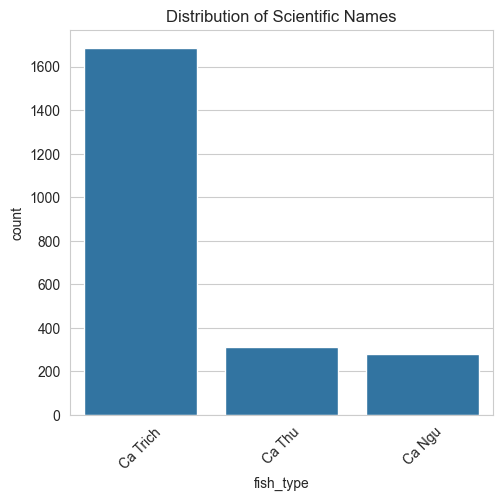

In [163]:
# Plot distribution of scientificName, occurrenceStatus
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=gbif_data_subset, x='fish_type', order=gbif_data_subset['fish_type'].value_counts().index)
plt.title('Distribution of Scientific Names')
plt.xticks(rotation=45)

([0, 1], [Text(0, 0, 'PRESENT'), Text(1, 0, 'ABSENT')])

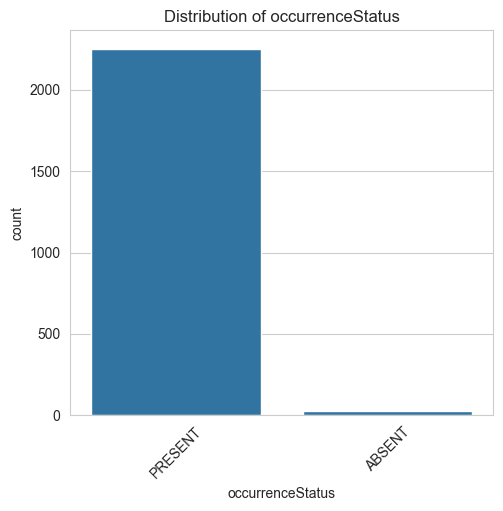

In [164]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=gbif_data_subset, x='occurrenceStatus', order=gbif_data_subset['occurrenceStatus'].value_counts().index)
plt.title('Distribution of occurrenceStatus')
plt.xticks(rotation=45)

/var/folders/yt/4vlc63d57rz84q0w40rbc23w0000gn/T/ipykernel_57687/2249994476.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


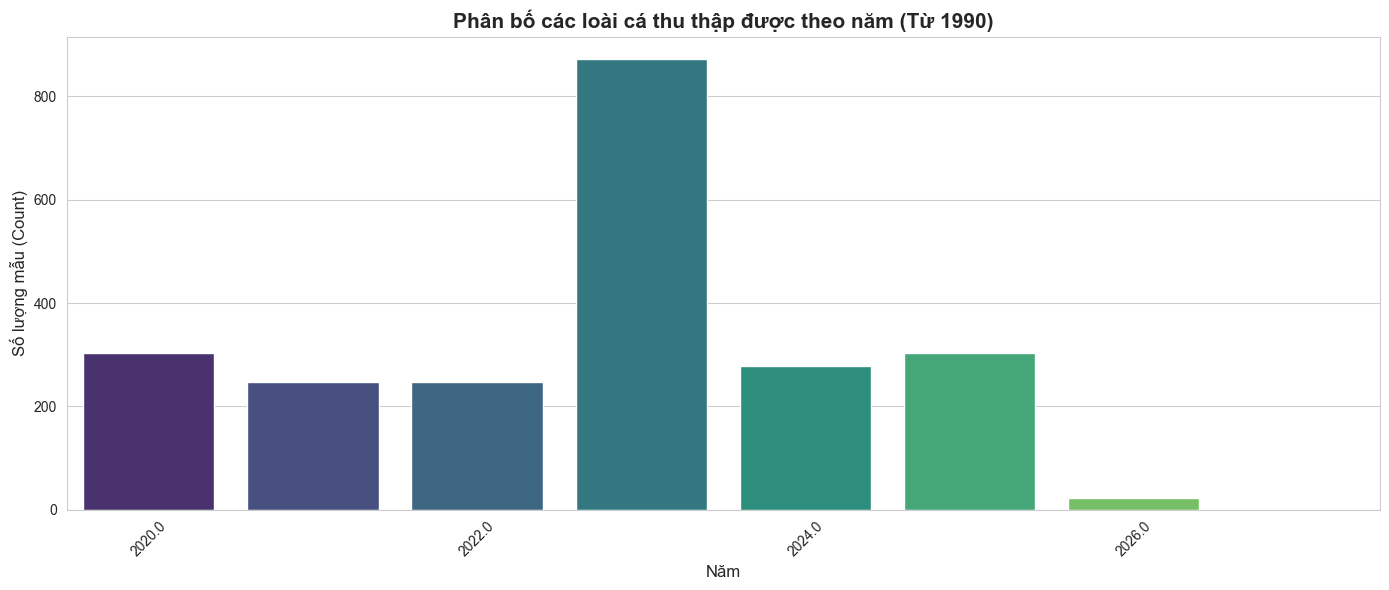

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập kích thước và style
plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")

# Sắp xếp dữ liệu theo năm tăng dần trước khi vẽ
year_order = sorted(gbif_data_subset['year'].unique())

# Vẽ biểu đồ
ax = sns.countplot(
    data=gbif_data_subset, 
    x='year', 
    order=year_order, 
    palette='viridis' # Màu sắc chuyển từ đậm sang nhạt theo thời gian
)

# Tinh chỉnh tiêu đề và nhãn
plt.title('Phân bố các loài cá thu thập được theo năm (Từ 1990)', fontsize=15, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Số lượng mẫu (Count)', fontsize=12)

# Xử lý trục X để không bị dày đặc chữ
# Cứ 2 hoặc 5 năm thì hiện nhãn 1 lần nếu dữ liệu quá dài
for i, label in enumerate(ax.get_xticklabels()):
    if i % 2 != 0: # Hiện mỗi 2 năm 1 lần, thay số 2 bằng số khác nếu cần
        label.set_visible(False)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [166]:
# Lọc dữ liệu trong khoảng 2022 - 2025
filtered_years = gbif_data_subset[(gbif_data_subset['year'] >= 2020) & (gbif_data_subset['year'] <= 2025)]

# Đếm số lượng và sắp xếp theo thứ tự năm
year_counts = filtered_years['year'].value_counts().sort_index()

print("Số lượng mẫu theo từng năm:")
print(year_counts)

Số lượng mẫu theo từng năm:
year
2020.0    304
2021.0    247
2022.0    247
2023.0    872
2024.0    278
2025.0    303
Name: count, dtype: int64


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33],
 [Text(0, 0, 'BD'),
  Text(1, 0, 'TW'),
  Text(2, 0, 'JP'),
  Text(3, 0, 'CN'),
  Text(4, 0, 'IN'),
  Text(5, 0, 'SG'),
  Text(6, 0, 'TH'),
  Text(7, 0, 'IL'),
  Text(8, 0, 'ID'),
  Text(9, 0, 'KR'),
  Text(10, 0, 'VN'),
  Text(11, 0, 'LK'),
  Text(12, 0, 'MY'),
  Text(13, 0, 'PH'),
  Text(14, 0, 'RU'),
  Text(15, 0, 'TR'),
  Text(16, 0, 'HK'),
  Text(17, 0, 'AE'),
  Text(18, 0, 'MV'),
  Text(19, 0, 'KH'),
  Text(20, 0, 'SA'),
  Text(21, 0, 'IQ'),
  Text(22, 0, 'GR'),
  Text(23, 0, 'OM'),
  Text(24, 0, 'EG'),
  Text(25, 0, 'GE'),
  Text(26, 0, 'MO'),
  Text(27, 0, 'CY'),
  Text(28, 0, 'CX'),
  Text(29, 0, 'TL'),
  Text(30, 0, 'IR'),
  Text(31, 0, 'PK'),
  Text(32, 0, 'MM'),
  Text(33, 0, 'IO')])

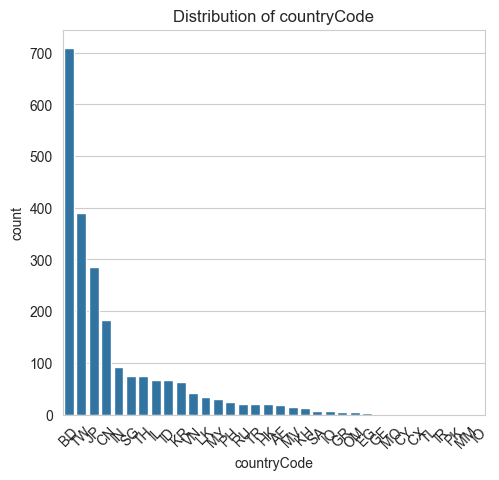

In [167]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=gbif_data_subset, x='countryCode', order=gbif_data_subset['countryCode'].value_counts().index)
plt.title('Distribution of countryCode')
plt.xticks(rotation=45)

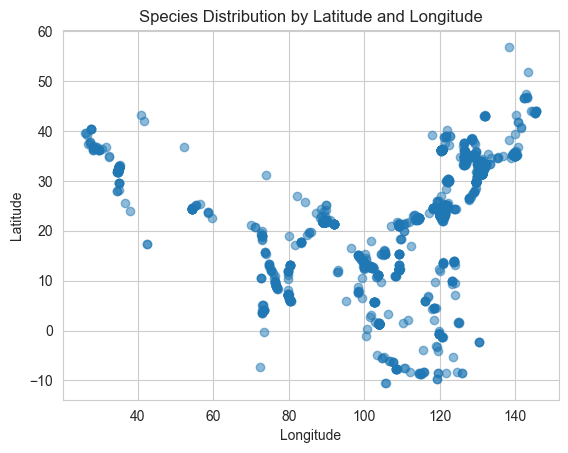

In [168]:
# distribution by lat long
import matplotlib.pyplot as plt
plt.scatter(gbif_data_subset['decimalLongitude'], gbif_data_subset['decimalLatitude'], alpha=0.5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Species Distribution by Latitude and Longitude')
plt.show()

In [169]:
import geopandas as gpd

url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
world = gpd.read_file(url)


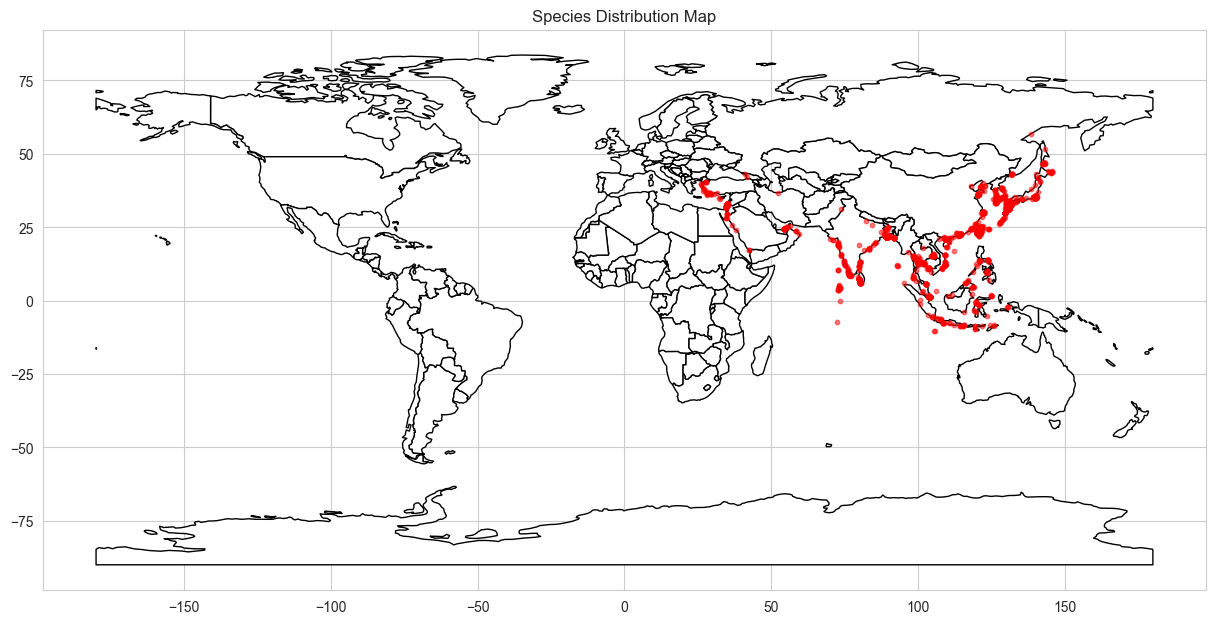

In [170]:
# Add map visualization
import geopandas as gpd
from shapely.geometry import Point 
geometry = [Point(xy) for xy in zip(gbif_data_subset['decimalLongitude'], gbif_data_subset['decimalLatitude'])]
geo_df = gpd.GeoDataFrame(gbif_data_subset, geometry=geometry)
world = gpd.read_file(url)
ax = world.plot(figsize=(15, 10), color='white', edgecolor='black')
geo_df.plot(ax=ax, markersize=10, color='red', alpha=0.5)
plt.title('Species Distribution Map')
plt.show()

File lưu csv đã xử lý:
- remove dữ liệu eventDate bị null, và trước 1990
- convert eventDate về dạng datetime64
- fillna với các column như day, month, year để tiện xử lý sau này
- species bị null thì sẽ đặt tên theo cú pháp là <genus> + other. Ví dụ Sardinella other - 1 loài cá trích khác
- số lượng cá từ năm 2022-2025 từ dữ liệu quá ít (chỉ 181) => Nên nếu xử lý cho model thì bị ít quá. Cần cân nhắc tiếp nè

In [171]:
# Export file to csv
#gbif_data_subset.to_csv('../dataset/gbif_asia_full_sardinella_scomber_thunner.csv')

# Read OBIS occurrence file and concat with GBIF_data_subset

In [ ]:
gbif_three_fish_type = gbif_data_subset

       gbifID     family          genus                 species countryCode  \
0  5069193733  Clupeidae    Amblygaster        Amblygaster sirm          TW   
1  5069190053  Clupeidae    Amblygaster        Amblygaster sirm          TW   
2  4930326497  Clupeidae  Anodontostoma  Anodontostoma chacunda          MY   
3  4930326656  Clupeidae  Anodontostoma  Anodontostoma chacunda          MY   
4  5865123310  Clupeidae  Anodontostoma  Anodontostoma chacunda          BD   

  stateProvince occurrenceStatus  individualCount  decimalLatitude  \
0           NaN          PRESENT              2.0        22.838060   
1           NaN          PRESENT              1.0        22.836917   
2           NaN          PRESENT              1.0         5.679000   
3           NaN          PRESENT              1.0         5.668000   
4           NaN          PRESENT              NaN        21.703521   

   decimalLongitude  ...  depth  depthAccuracy   eventDate   day  month  \
0        121.189425  ...    N

In [173]:
obis_fish = pd.read_csv('../dataset/obis/obis_occurrence_asia_clupea_scomber_thunnus.csv')
obis_fish.shape

(129, 6)

In [174]:
print(obis_fish.columns)

Index(['genus', 'common_name_vi', 'scientificName', 'decimalLatitude',
       'decimalLongitude', 'eventDate'],
      dtype='object')


In [175]:
# Unique value of categorical columns
categorical_columns = ['genus', 'common_name_vi', 'scientificName']
for col in categorical_columns:
    unique_values = obis_fish[col].unique()
    print(f"Unique values in column '{col}': {unique_values}")

Unique values in column 'genus': ['Clupea' 'Scomber' 'Thunnus']
Unique values in column 'common_name_vi': ['Cá Trích' 'Cá Thu' 'Cá Ngừ']
Unique values in column 'scientificName': ['Clupea' 'Clupea pallasii' 'Scomber japonicus' 'Scomber australasicus'
 'Thunnus' 'Thunnus albacares']


In [176]:
# 1. Mapping dictionary to add column 'fish_type' and rename to map with GBIF dataframe
mapping = {
    'Cá Ngừ': 'Ca Ngu',
    'Cá Thu': 'Ca Thu',
    'Cá Trích': 'Ca Trich',
    'Mực': 'Muc'
}

# 2. Tạo cột 'fish_type' bằng cách ánh xạ từ cột 'common_vi_name'
obis_fish['fish_type'] = obis_fish['common_name_vi'].map(mapping)

# 3. Làm sạch dữ liệu: Loại bỏ những dòng không thuộc danh mục mục tiêu
obis_fish = obis_fish.dropna(subset=['fish_type'])

In [177]:
print(obis_fish.head(5))

    genus common_name_vi scientificName  decimalLatitude  decimalLongitude  \
0  Clupea       Cá Trích         Clupea        -9.446171         46.210988   
1  Clupea       Cá Trích         Clupea         8.848100        119.932083   
2  Clupea       Cá Trích         Clupea         8.804517        119.825967   
3  Clupea       Cá Trích         Clupea        -9.369519         46.450737   
4  Clupea       Cá Trích         Clupea        21.756580         89.223058   

              eventDate fish_type  
0  2023-04-24T04:55:32Z  Ca Trich  
1            2023-04-14  Ca Trich  
2            2023-04-15  Ca Trich  
3  2023-03-27T05:23:53Z  Ca Trich  
4            2023-01-08  Ca Trich  


In [178]:
print(obis_fish.shape)

(129, 7)


In [179]:
print(gbif_three_fish_type.columns)

Index(['gbifID', 'family', 'genus', 'species', 'countryCode', 'stateProvince',
       'occurrenceStatus', 'individualCount', 'decimalLatitude',
       'decimalLongitude', 'coordinateUncertaintyInMeters', 'depth',
       'depthAccuracy', 'eventDate', 'day', 'month', 'year', 'basisOfRecord',
       'fish_type', 'datetime', 'date'],
      dtype='object')


In [180]:
gbif_three_fish_type.shape

(2277, 21)

In [181]:
# Check column gbif_five_species_cleaned['date] => convert sang năm và lấy từ range 2020-> 2025
gbif_three_fish_type = gbif_three_fish_type[gbif_three_fish_type['year'].between(2020, 2025)]

In [182]:
gbif_three_fish_type.shape

(2251, 21)

In [183]:
# Thêm source column để phân biệt dữ liệu từ gbif hoặc obis
gbif_three_fish_type['source'] = 'gbif'
obis_fish['source'] = 'obis'

/var/folders/yt/4vlc63d57rz84q0w40rbc23w0000gn/T/ipykernel_57687/3680919313.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gbif_three_fish_type['source'] = 'gbif'


In [184]:
print(gbif_three_fish_type['occurrenceStatus'].unique())

['PRESENT' 'ABSENT']


Xử lý occurenceStatus

Do dữ liệu của gbif_three_fish_type có 'occurrenceStatus' thể hiện cho presence và absence tuy khá là imbalance class nhưng sau này cũng cần phải pseuedo generate nên để đồng bộ dữ liệu, từ obis dữ liệu mình sẽ thêm cột ''occurrenceStatus' và dánh dấu toàn bộ là presence

In [186]:
# Mapping PRESENT = 1, ABSENT = 0 cho column occurenceStatus của gbif_three_fish_type
status_map = {
    'PRESENT': 1,
    'ABSENT': 0
}

gbif_three_fish_type['occurrenceStatus'] = gbif_three_fish_type['occurrenceStatus'].map(status_map)

gbif_three_fish_type['occurrenceStatus'] = gbif_three_fish_type['occurrenceStatus'].fillna(1)

# Thêm cột occurenceStatus cho obis_fish và đánh dấu là 1 hết
obis_fish['occurrenceStatus'] = 1

/var/folders/yt/4vlc63d57rz84q0w40rbc23w0000gn/T/ipykernel_57687/1207051135.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gbif_three_fish_type['occurrenceStatus'] = gbif_three_fish_type['occurrenceStatus'].map(status_map)
/var/folders/yt/4vlc63d57rz84q0w40rbc23w0000gn/T/ipykernel_57687/1207051135.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gbif_three_fish_type['occurrenceStatus'] = gbif_three_fish_type['occurrenceStatus'].fillna(1)


In [187]:
#Concat obis_fish and gbif_data
import pandas as pd

# Concat
obis_fish_gbif = pd.concat([obis_fish[['fish_type', 'genus', 'decimalLatitude','decimalLongitude', 'eventDate', 'occurrenceStatus', 'source']], 
                            gbif_three_fish_type[['fish_type', 'genus', 'decimalLatitude','decimalLongitude','eventDate','occurrenceStatus', 'source']]]
                            , ignore_index=True) 
print(obis_fish_gbif.info())
# %%
print(obis_fish_gbif.shape)
# %%
print(obis_fish_gbif.describe())
# %%
print(obis_fish_gbif.head())
# %%
#obis_fish_gbif.to_csv('../dataset/obis_fish_gbif.csv')
# %%

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2380 entries, 0 to 2379
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fish_type         2380 non-null   object 
 1   genus             2305 non-null   object 
 2   decimalLatitude   2359 non-null   float64
 3   decimalLongitude  2359 non-null   float64
 4   eventDate         2380 non-null   object 
 5   occurrenceStatus  2380 non-null   float64
 6   source            2380 non-null   object 
dtypes: float64(3), object(4)
memory usage: 130.3+ KB
None
(2380, 7)
       decimalLatitude  decimalLongitude  occurrenceStatus
count      2359.000000       2359.000000            2380.0
mean         21.129261        101.439573               1.0
std          11.085206         25.615069               0.0
min         -10.497402         26.104022               1.0
25%          21.078000         89.260995               1.0
50%          21.793313        103.911901        

([0, 1, 2],
 [Text(0, 0, 'Ca Trich'), Text(1, 0, 'Ca Ngu'), Text(2, 0, 'Ca Thu')])

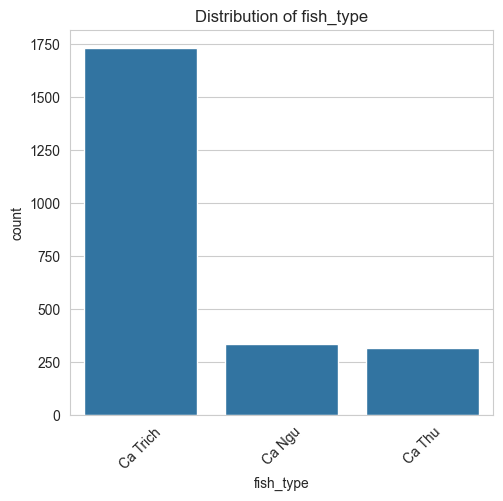

In [188]:
# Plot distribution of scientificName, occurrenceStatus
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=obis_fish_gbif, x='fish_type', order=obis_fish_gbif['fish_type'].value_counts().index)
plt.title('Distribution of fish_type')
plt.xticks(rotation=45)

- Sardinella: thuộc họ Family Clupeidae (Họ cá Trích)
- Thunnus: thuộc họ Scombridae (Họ cá thu ngừ), cá ngừ đại dương (cá ngừ vây vàng, cá ngừ mắt to, cá ngừ vây xanh)
- Scomber: thuộc ho Scombridae (Họ cá thu ngừ), cá thu ví dụ cá thu nhật
- Clupea: thuộc họ cá trích điển hình, gồm cá trích điển hình

Sardinella vs. Clupea: Cả hai đều thuộc họ Cá trích (Clupeidae), nhưng chúng thuộc các chi khác nhau với các loài đặc trưng riêng.

Thunnus vs. Scomber: Cả hai đều thuộc họ Cá thu ngừ (Scombridae), nhưng khác nhau về chi. Chi Thunnus đại diện cho các loài "cá ngừ" (tuna), trong khi chi Scomber đại diện cho các loài "cá thu" (mackerel).


In [189]:
obis_fish_gbif.columns

Index(['fish_type', 'genus', 'decimalLatitude', 'decimalLongitude',
       'eventDate', 'occurrenceStatus', 'source'],
      dtype='object')

([0, 1], [Text(0, 0, 'gbif'), Text(1, 0, 'obis')])

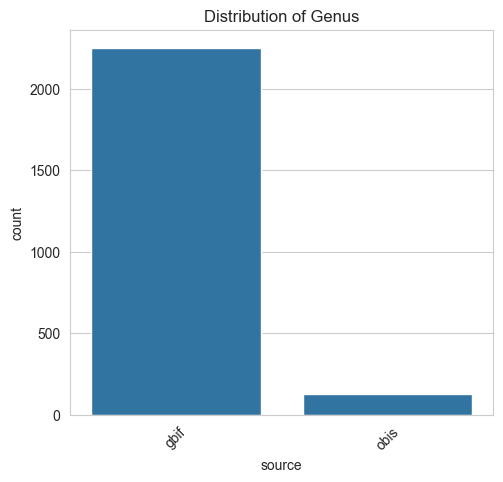

In [190]:
# Plot distribution of scientificName, occurrenceStatus
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=obis_fish_gbif, x='source', order=obis_fish_gbif['source'].value_counts().index)
plt.title('Distribution of Genus')
plt.xticks(rotation=45)

In [191]:
obis_fish_gbif.shape

(2380, 7)

In [192]:
# Save csv file
obis_fish_gbif.to_csv('obis_gbif_asia_2020_2025_trich_thu_ngu.csv', index=False)